# Dental X-ray Dataset: Merge + EDA

Combines two X-ray object-detection sources into one YOLO-bbox dataset scoped to the
sprint's 4-class list: **Cavity, Filling, Crown, Impacted Tooth**.

Sources:
- `Dental X-ray.v1i.yolov11/` — axis-aligned YOLO bbox labels, 4 classes (Cavity, Fillings, Impacted Tooth, Implant)
- `Dental X-Ray Panoramic Dataset/YOLO/YOLO/` — YOLO segmentation-polygon labels, 31 classes

The intraoral-photo "Cavity Dataset" is intentionally excluded — different imaging modality
(photos vs. X-ray), see project notes for the reasoning.

Only instances belonging to the 4 target classes are kept. Polygons from the panoramic
source are converted to axis-aligned boxes (min/max of the polygon points). Images left
with zero target-class instances after filtering are dropped.

In [1]:
import os
import shutil

import cv2
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
pd.set_option("display.max_columns", None)

## 1. Environment setup

Run this cell first. It detects whether you're on Colab or running locally and points
`DOWNLOADS` at the right place:

- **Colab**: mounts your Google Drive, then copies+extracts the two dataset zips from
  `MyDrive/Dental Cavity Detection/` into local Colab disk (`/content/dental_data`) for
  fast image I/O — reading thousands of small files directly off Drive is very slow.
  Edit `DRIVE_PROJECT_FOLDER` below if you used a different folder name.
- **Local**: uses `~/Downloads`, same as before.

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import zipfile

    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_PROJECT_FOLDER = "/content/drive/MyDrive/Dental Cavity Detection"
    DOWNLOADS = "/content/dental_data"
    os.makedirs(DOWNLOADS, exist_ok=True)

    zip_names = ["Dental X-ray.v1i.yolov11.zip", "Dental X-Ray Panoramic Dataset.zip"]
    for zip_name in zip_names:
        zip_path = os.path.join(DRIVE_PROJECT_FOLDER, zip_name)
        marker = os.path.join(DOWNLOADS, zip_name + ".extracted")
        if os.path.exists(marker):
            print(f"Already extracted: {zip_name}")
            continue
        if not os.path.exists(zip_path):
            raise FileNotFoundError(
                f"Expected {zip_path} \n"
                "Upload the dataset zip to that Drive folder first (see upload instructions)."
            )
        print(f"Extracting {zip_name} ...")
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(DOWNLOADS)
        open(marker, "w").close()
        print(f"Done: {zip_name}")
else:
    DOWNLOADS = os.path.expanduser("~/Downloads")

print(f"\nIN_COLAB = {IN_COLAB}")
print(f"Using data root: {DOWNLOADS}")

Mounted at /content/drive
Extracting Dental X-ray.v1i.yolov11.zip ...
Done: Dental X-ray.v1i.yolov11.zip
Extracting Dental X-Ray Panoramic Dataset.zip ...
Done: Dental X-Ray Panoramic Dataset.zip

IN_COLAB = True
Using data root: /content/dental_data


## 3. Config

In [3]:
SOURCE_A = os.path.join(DOWNLOADS, "Dental X-ray.v1i.yolov11")
SOURCE_B = os.path.join(DOWNLOADS, "Dental X-Ray Panoramic Dataset", "YOLO", "YOLO")
OUTPUT = os.path.join(DOWNLOADS, "Combined Dental Dataset")

TARGET_CLASSES = ["Cavity", "Filling", "Crown", "Impacted Tooth"]
TARGET_INDEX = {name: i for i, name in enumerate(TARGET_CLASSES)}

# source class name -> target class name
CLASS_MAP_A = {
    "Cavity": "Cavity",
    "Fillings": "Filling",
    "Impacted Tooth": "Impacted Tooth",
    "Implant": None,  # not in target list
}
CLASS_MAP_B = {
    "Caries": "Cavity",
    "Crown": "Crown",
    "Filling": "Filling",
    "impacted tooth": "Impacted Tooth",
    # everything else in the 31-class list maps to None (dropped)
}

SPLITS = ["train", "valid", "test"]

## 4. Merge helpers

In [4]:
def read_yolo_names(data_yaml_path):
    """Minimal YAML parser for the `names:` block (avoids a pyyaml dependency)."""
    names = {}
    in_names_block = False
    with open(data_yaml_path) as f:
        for line in f:
            stripped = line.strip()
            if stripped.startswith("names:"):
                inline = stripped[len("names:"):].strip()
                if inline.startswith("["):
                    items = [s.strip().strip("'\"") for s in inline.strip("[]").split(",")]
                    return {i: n for i, n in enumerate(items)}
                in_names_block = True
                continue
            if in_names_block:
                if not stripped or ":" not in line:
                    break
                idx_str, name = line.split(":", 1)
                names[int(idx_str.strip())] = name.strip()
    return names


def build_index_map(names_by_idx, class_map):
    """source_class_idx -> target_class_idx (or None if dropped)."""
    lower_map = {k.lower(): v for k, v in class_map.items()}
    result = {}
    for idx, name in names_by_idx.items():
        target_name = lower_map.get(name.strip().lower())
        result[idx] = TARGET_INDEX[target_name] if target_name else None
    return result


def convert_label_line_bbox(parts, index_map):
    """Source A: `class x y w h` (already axis-aligned) -> re-map class only."""
    src_idx = int(parts[0])
    target_idx = index_map.get(src_idx)
    if target_idx is None:
        return None
    return f"{target_idx} {' '.join(parts[1:5])}"


def convert_label_line_polygon(parts, index_map):
    """Source B: `class x1 y1 x2 y2 ... xn yn` polygon -> axis-aligned bbox."""
    src_idx = int(parts[0])
    target_idx = index_map.get(src_idx)
    if target_idx is None:
        return None

    coords = list(map(float, parts[1:]))
    xs = coords[0::2]
    ys = coords[1::2]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)
    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    w = x_max - x_min
    h = y_max - y_min
    return f"{target_idx} {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}"


def process_source(source_root, prefix, index_map, line_converter, stats):
    for split in SPLITS:
        image_dir = os.path.join(source_root, split, "images")
        label_dir = os.path.join(source_root, split, "labels")
        if not os.path.isdir(image_dir):
            continue

        out_image_dir = os.path.join(OUTPUT, split, "images")
        out_label_dir = os.path.join(OUTPUT, split, "labels")
        os.makedirs(out_image_dir, exist_ok=True)
        os.makedirs(out_label_dir, exist_ok=True)

        for image_name in os.listdir(image_dir):
            stem, ext = os.path.splitext(image_name)
            label_path = os.path.join(label_dir, stem + ".txt")
            if not os.path.isfile(label_path):
                continue

            with open(label_path) as f:
                raw_lines = [l.split() for l in f if l.strip()]

            kept_lines = []
            for parts in raw_lines:
                converted = line_converter(parts, index_map)
                if converted is not None:
                    kept_lines.append(converted)

            stats["images_seen"][split] += 1
            if not kept_lines:
                stats["images_dropped_empty"][split] += 1
                continue

            new_stem = f"{prefix}_{stem}"
            shutil.copyfile(os.path.join(image_dir, image_name), os.path.join(out_image_dir, new_stem + ext))
            with open(os.path.join(out_label_dir, new_stem + ".txt"), "w") as f:
                f.write("\n".join(kept_lines) + "\n")

            stats["images_kept"][split] += 1
            for line in kept_lines:
                cls_idx = int(line.split()[0])
                stats["instance_counts"][TARGET_CLASSES[cls_idx]] += 1

## 5. Run the merge

Re-running this cell rebuilds `Combined Dental Dataset/` from scratch.

In [5]:
if os.path.isdir(OUTPUT):
    shutil.rmtree(OUTPUT)

names_a = read_yolo_names(os.path.join(SOURCE_A, "data.yaml"))
names_b = read_yolo_names(os.path.join(SOURCE_B, "data.yaml"))
index_map_a = build_index_map(names_a, CLASS_MAP_A)
index_map_b = build_index_map(names_b, CLASS_MAP_B)

stats = {
    "images_seen": {s: 0 for s in SPLITS},
    "images_kept": {s: 0 for s in SPLITS},
    "images_dropped_empty": {s: 0 for s in SPLITS},
    "instance_counts": {c: 0 for c in TARGET_CLASSES},
}

print("Source A classes kept:", {names_a[i]: TARGET_CLASSES[t] for i, t in index_map_a.items() if t is not None})
print("Source B classes kept:", {names_b[i]: TARGET_CLASSES[t] for i, t in index_map_b.items() if t is not None})

process_source(SOURCE_A, "xray1", index_map_a, convert_label_line_bbox, stats)
process_source(SOURCE_B, "panoramic", index_map_b, convert_label_line_polygon, stats)

with open(os.path.join(OUTPUT, "data.yaml"), "w") as f:
    f.write("train: train/images\nval: valid/images\ntest: test/images\n\n")
    f.write(f"nc: {len(TARGET_CLASSES)}\n")
    f.write(f"names: {TARGET_CLASSES}\n")

print(f"\nCombined dataset written to: {OUTPUT}")

Source A classes kept: {'Cavity': 'Cavity', 'Fillings': 'Filling', 'Impacted Tooth': 'Impacted Tooth'}
Source B classes kept: {'Caries': 'Cavity', 'Crown': 'Crown', 'Filling': 'Filling', 'impacted tooth': 'Impacted Tooth'}

Combined dataset written to: /content/dental_data/Combined Dental Dataset


In [6]:
for split in SPLITS:
    print(f"{split}: seen={stats['images_seen'][split]} "
          f"kept={stats['images_kept'][split]} "
          f"dropped(no target-class objects)={stats['images_dropped_empty'][split]}")

print("\nInstance counts (target classes only):")
for cls, count in stats["instance_counts"].items():
    print(f"  {cls}: {count}")

train: seen=10234 kept=10023 dropped(no target-class objects)=211
valid: seen=3086 kept=3044 dropped(no target-class objects)=42
test: seen=1687 kept=1665 dropped(no target-class objects)=22

Instance counts (target classes only):
  Cavity: 11300
  Filling: 54270
  Crown: 11252
  Impacted Tooth: 28406


## 6. EDA on the combined dataset

Filenames are prefixed by source dataset (`xray1_...` or `panoramic_...`) so we can also
compare distributions across the two merged sources.

In [7]:
def source_of(filename: str) -> str:
    return "xray1" if filename.startswith("xray1_") else "panoramic"


def load_annotations(dataset_root=OUTPUT):
    rows = []
    for split in SPLITS:
        label_dir = os.path.join(dataset_root, split, "labels")
        image_dir = os.path.join(dataset_root, split, "images")
        if not os.path.isdir(label_dir):
            continue

        for fname in os.listdir(label_dir):
            if not fname.endswith(".txt"):
                continue
            stem = fname[:-4]
            image_files = [f for f in os.listdir(image_dir) if f.startswith(stem + ".")]
            image_path = os.path.join(image_dir, image_files[0]) if image_files else None

            with open(os.path.join(label_dir, fname)) as f:
                lines = [l.split() for l in f if l.strip()]

            for parts in lines:
                cls_idx = int(parts[0])
                x, y, w, h = map(float, parts[1:5])
                rows.append({
                    "split": split, "source": source_of(stem), "image": stem,
                    "image_path": image_path, "class": TARGET_CLASSES[cls_idx],
                    "x_center": x, "y_center": y, "bbox_w": w, "bbox_h": h,
                    "bbox_area_norm": w * h,
                })

    return pd.DataFrame(rows)


def load_image_metadata(dataset_root=OUTPUT):
    rows = []
    for split in SPLITS:
        image_dir = os.path.join(dataset_root, split, "images")
        if not os.path.isdir(image_dir):
            continue
        for fname in os.listdir(image_dir):
            path = os.path.join(image_dir, fname)
            img = cv2.imread(path)
            if img is None:
                rows.append({"split": split, "source": source_of(fname), "image": fname,
                             "width": None, "height": None, "corrupt": True})
                continue
            h, w = img.shape[:2]
            rows.append({"split": split, "source": source_of(fname), "image": fname,
                         "width": w, "height": h, "corrupt": False})
    return pd.DataFrame(rows)


annotations = load_annotations()
images = load_image_metadata()
print(f"{len(images)} images, {len(annotations)} object instances loaded")

14732 images, 105228 object instances loaded


### Image counts per split / source

In [8]:
images.groupby(["split", "source"]).size().unstack(fill_value=0)

source,panoramic,xray1
split,,
test,1569,96
train,9295,728
valid,2839,205


### Corrupt / unreadable images

In [9]:
corrupt = images[images["corrupt"]]
print(f"{len(corrupt)} corrupt image(s)" if len(corrupt) else "None found")
corrupt

None found


,split,source,image,width,height,corrupt


### Image resolution stats by source

In [10]:
images.groupby("source")[["width", "height"]].describe()

width                                                        \
             count         mean         std    min    25%    50%     75%   
source                                                                     
panoramic  13703.0  1028.064657  477.268777  640.0  640.0  640.0  1615.0   
xray1       1029.0   640.000000    0.000000  640.0  640.0  640.0   640.0   

                    height                                                     \
              max    count        mean        std    min    25%    50%    75%   
source                                                                          
panoramic  1615.0  13703.0  719.603007  97.901288  640.0  640.0  640.0  840.0   
xray1       640.0   1029.0  640.000000   0.000000  640.0  640.0  640.0  640.0   

                  
             max  
source            
panoramic  840.0  
xray1      640.0

### Class balance per split

In [11]:
pd.crosstab(annotations["split"], annotations["class"])

class,Cavity,Crown,Filling,Impacted Tooth
split,,,,
test,1228,1157,6133,3300
train,7748,8008,37005,19179
valid,2324,2087,11132,5927


### Class balance by source dataset

This is the key sanity check for the merge: `xray1` contributes zero `Crown` labels, and the two sources are very unevenly sized, so any train/val/test split should be stratified by source, not just shuffled.

In [12]:
pd.crosstab(annotations["source"], annotations["class"])

class,Cavity,Crown,Filling,Impacted Tooth
source,,,,
panoramic,10724,11252,49031,27978
xray1,576,0,5239,428


### Bounding box size stats (normalized 0-1)

In [13]:
annotations.groupby("class")[["bbox_w", "bbox_h", "bbox_area_norm"]].describe()

bbox_w                                                    \
                  count      mean       std       min       25%       50%   
class                                                                       
Cavity          11300.0  0.022434  0.016178  0.003086  0.011077  0.017259   
Crown           11252.0  0.052403  0.029602  0.001005  0.036002  0.047264   
Filling         54270.0  0.041006  0.017342  0.000352  0.030764  0.040179   
Impacted Tooth  28406.0  0.075149  0.022514  0.020309  0.059784  0.073144   

                                     bbox_h                                \
                     75%       max    count      mean       std       min   
class                                                                       
Cavity          0.028916  0.358323  11300.0  0.049264  0.032911  0.004788   
Crown           0.058891  0.490865  11252.0  0.077966  0.016496  0.022283   
Filling         0.050105  1.047532  54270.0  0.065139  0.042884  0.003906   
Impacted Tooth  0.086861  0.423231  28406.0  0.128353  0.023447  0.022136   

                                                       bbox_area_norm  \
                     25%       50%       75%       max          count   
class                                                                   
Cavity          0.029277  0.041078  0.058590  0.261719        11300.0   
Crown           0.067597  0.076594  0.086483  0.199825        11252.0   
Filling         0.038511  0.053527  0.076000  0.900211        54270.0   
Impacted Tooth  0.110392  0.125881  0.144531  0.270008        28406.0   

                                                                            \
                    mean       std       min       25%       50%       75%   
class                                                                        
Cavity          0.001422  0.001988  0.000041  0.000340  0.000688  0.001655   
Crown           0.004277  0.003722  0.000022  0.002639  0.003512  0.004700   
Filling         0.002948  0.004857  0.000003  0.001279  0.002163  0.003656   
Impacted Tooth  0.009665  0.003576  0.000701  0.007313  0.008920  0.011190   

                          
                     max  
class                     
Cavity          0.020452  
Crown           0.082656  
Filling         0.943000  
Impacted Tooth  0.055609

### Plots: class balance

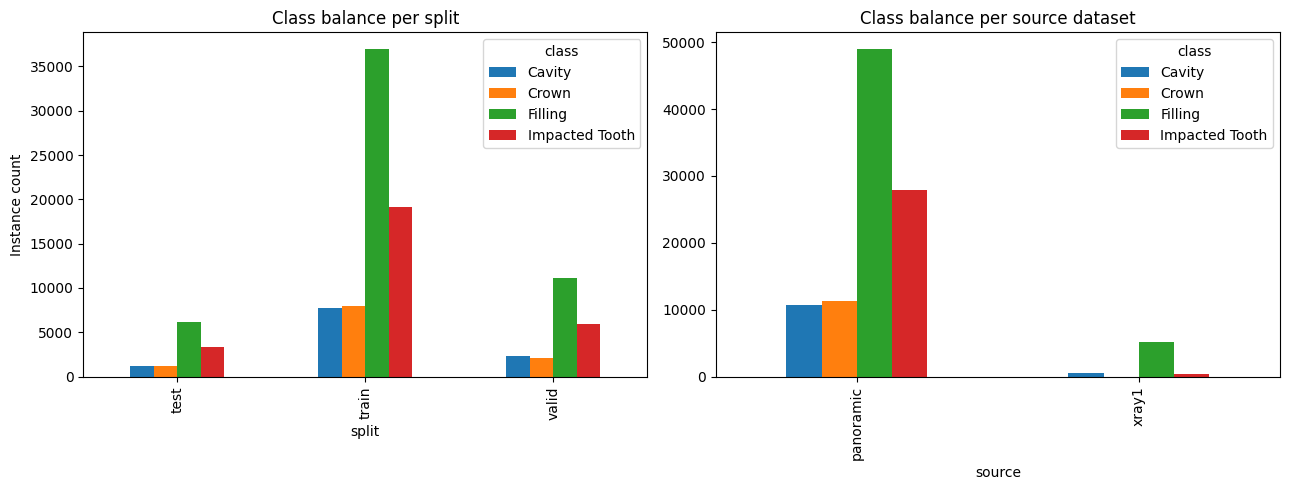

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

annotations.groupby(["split", "class"]).size().unstack(fill_value=0).plot(kind="bar", ax=axes[0])
axes[0].set_title("Class balance per split")
axes[0].set_ylabel("Instance count")

annotations.groupby(["source", "class"]).size().unstack(fill_value=0).plot(kind="bar", ax=axes[1])
axes[1].set_title("Class balance per source dataset")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "eda_class_balance.png"))
plt.show()

### Plots: image quality

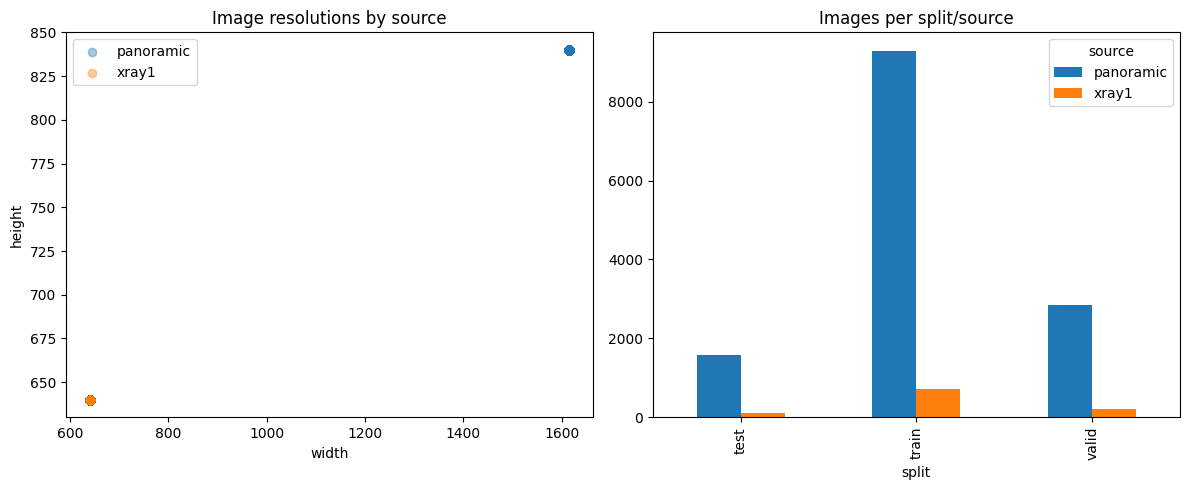

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for source, group in images.groupby("source"):
    axes[0].scatter(group["width"], group["height"], alpha=0.4, label=source)
axes[0].set_xlabel("width")
axes[0].set_ylabel("height")
axes[0].set_title("Image resolutions by source")
axes[0].legend()

images.groupby(["split", "source"]).size().unstack(fill_value=0).plot(kind="bar", ax=axes[1])
axes[1].set_title("Images per split/source")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "eda_image_quality.png"))
plt.show()

### Sample images with boxes drawn

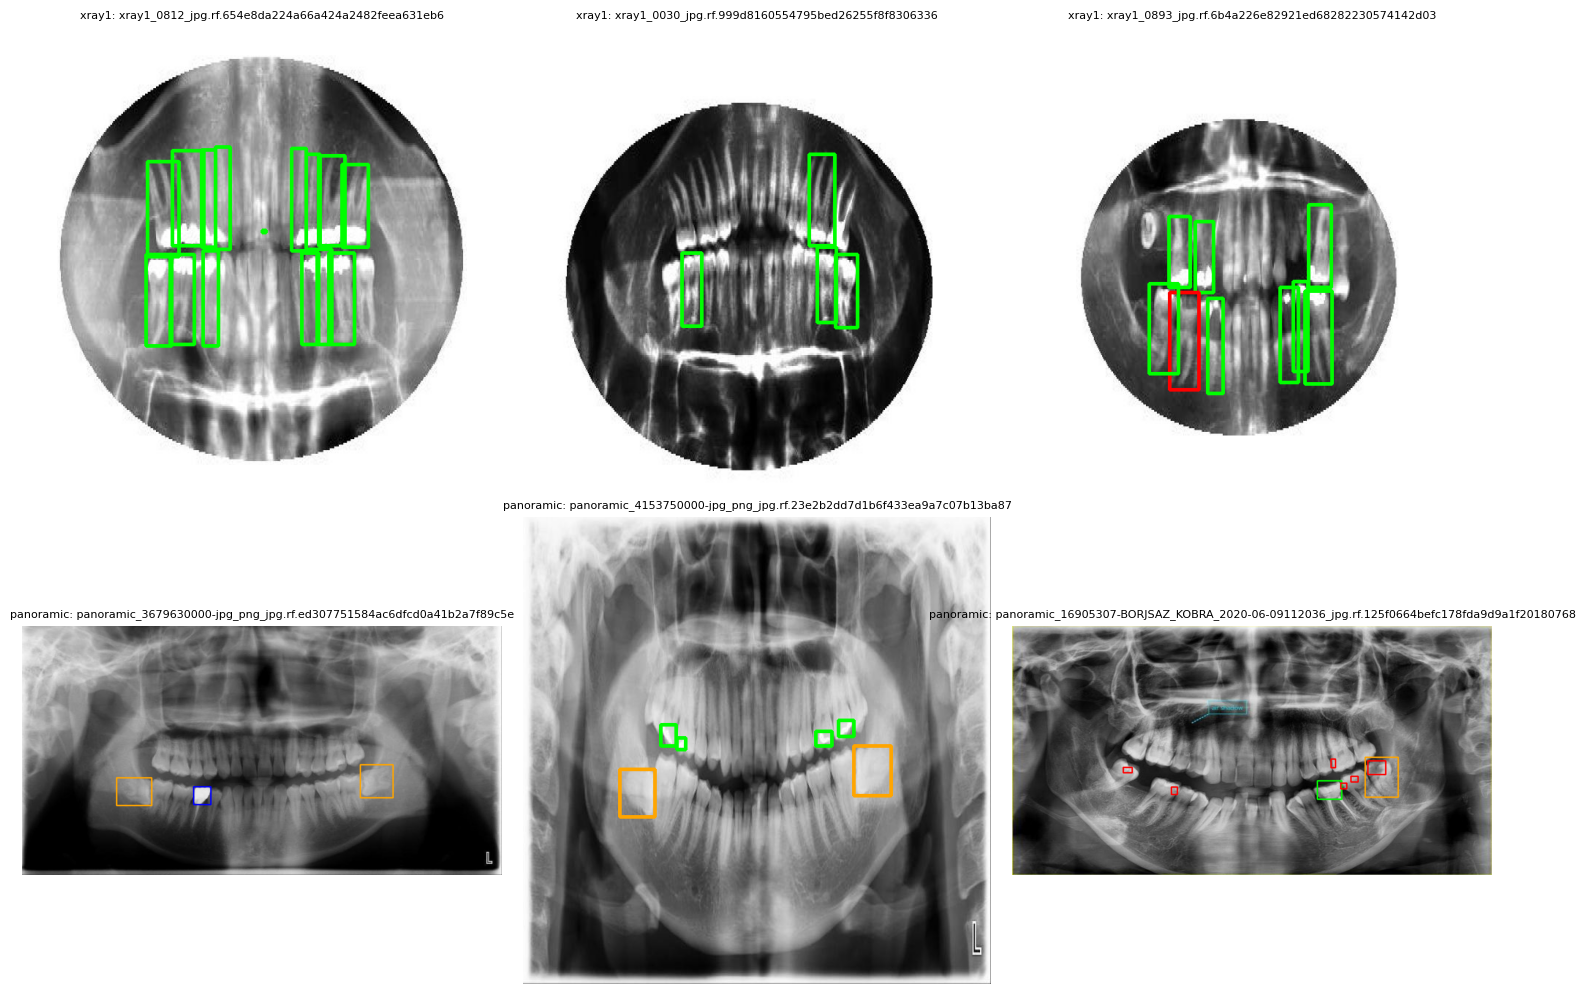

In [16]:
def draw_boxes(image_path, boxes):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    colors = {"Cavity": (255, 0, 0), "Filling": (0, 255, 0), "Crown": (0, 0, 255), "Impacted Tooth": (255, 165, 0)}
    for _, row in boxes.iterrows():
        x1 = int((row["x_center"] - row["bbox_w"] / 2) * w)
        y1 = int((row["y_center"] - row["bbox_h"] / 2) * h)
        x2 = int((row["x_center"] + row["bbox_w"] / 2) * w)
        y2 = int((row["y_center"] + row["bbox_h"] / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), colors[row["class"]], 3)
    return img


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for row_i, source in enumerate(["xray1", "panoramic"]):
    sample_images = annotations[annotations["source"] == source]["image"].unique()[:3]
    for col_i, image_name in enumerate(sample_images):
        boxes = annotations[annotations["image"] == image_name]
        img = draw_boxes(boxes.iloc[0]["image_path"], boxes)
        axes[row_i, col_i].imshow(img)
        axes[row_i, col_i].set_title(f"{source}: {image_name}", fontsize=8)
        axes[row_i, col_i].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT, "eda_sample_boxes.png"))
plt.show()

### Save outputs

In [17]:
annotations.to_csv(os.path.join(OUTPUT, "annotations_long.csv"), index=False)
images.to_csv(os.path.join(OUTPUT, "image_metadata.csv"), index=False)
print("Saved annotations_long.csv and image_metadata.csv")

Saved annotations_long.csv and image_metadata.csv


## 7. Key findings

- **Source imbalance**: the panoramic dataset dominates ~13:1 in image count over `xray1`, and supplies nearly all `Crown` instances — `xray1` contributes zero. Splitting/evaluating without stratifying by source will mostly measure performance on panoramic images.
- **Class imbalance**: `Filling` instances (~54k) outnumber `Cavity` and `Crown` (~11k each) by roughly 5:1 — expect a baseline model to be biased toward predicting Filling.
- **Resolution mismatch**: `xray1` images are uniformly 640x640 (pre-resized by Roboflow); panoramic images vary between 640-840px per side.

Worth raising with the team before the baseline YOLO run: whether to stratify sampling by source, and whether to apply class-weighted loss or oversampling for Cavity/Crown.